In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cargamos el dataset preparado para el Modelo A

df = pd.read_csv("data_limpio/features_modelo_A.csv")

df["Time"] = pd.to_datetime(df["Time"])

df.head()

,Time,bloque,LT411,DT412,INT_P101,FQC400_1,FV400_1,PT442,PV442,TT413,...,TT415_roll_mean_6,TT415_roll_std_6,PIT410_roll_mean_3,PIT410_roll_std_3,PIT410_roll_mean_6,PIT410_roll_std_6,PIT414_roll_mean_3,PIT414_roll_std_3,PIT414_roll_mean_6,PIT414_roll_std_6
0,2021-11-05 08:01:00,train,62.456596,1230.325464,56.212383,3047.721924,59.5,0.154340,0.0,80.920140,...,81.807006,0.013907,0.325703,0.000903,0.326006,0.000664,0.578453,0.000385,0.578742,0.000485
1,2021-11-05 08:01:10,train,62.248263,1229.934875,57.853009,3038.804883,59.5,0.154167,0.0,80.933161,...,81.799772,0.019540,0.325183,0.000730,0.325783,0.000803,0.579051,0.000796,0.578819,0.000635
2,2021-11-05 08:01:20,train,61.163193,1229.869763,57.760415,3038.722290,59.5,0.154398,0.0,80.946182,...,81.795431,0.018551,0.325045,0.000493,0.325650,0.000744,0.579205,0.000619,0.578781,0.000625
3,2021-11-05 08:01:30,train,60.925924,1229.700464,57.421874,3038.415259,59.5,0.154427,0.0,80.928821,...,81.795431,0.018551,0.325279,0.000393,0.325491,0.000665,0.579012,0.000827,0.578733,0.000653
4,2021-11-05 08:01:40,train,61.125578,1229.830701,57.025462,3044.414307,59.5,0.153906,0.0,80.911459,...,81.794708,0.017737,0.325374,0.000239,0.325279,0.000497,0.578607,0.000273,0.578829,0.000585


In [3]:
# Separamos el dataset por bloques temporales

train = df[df["bloque"] == "train"].copy()

valid = df[df["bloque"] == "validacion"].copy()

test = df[df["bloque"] == "test"].copy()

In [4]:
# Definimos variables predictoras y target

columnas_no_modelo = ["Time", "bloque", "LT411"]

X_train = train.drop(columns=columnas_no_modelo)
y_train = train["LT411"]

X_valid = valid.drop(columns=columnas_no_modelo)
y_valid = valid["LT411"]

X_test = test.drop(columns=columnas_no_modelo)
y_test = test["LT411"]

In [5]:
# Revisamos tamaños de X e y

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8634, 97)
y_train: (8634,)
X_valid: (8634, 97)
y_valid: (8634,)
X_test: (5784, 97)
y_test: (5784,)


In [7]:
# Importamos modelos y métricas de evaluación

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Creamos una función simple para calcular métricas de regresión

def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    return mae, rmse, r2

In [10]:
# Creamos un modelo Random Forest limitado para reducir sobreajuste

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
# Calculamos predicciones en train y validación

pred_train_rf = modelo_rf.predict(X_train)

pred_valid_rf = modelo_rf.predict(X_valid)

In [12]:
# Calculamos métricas del Random Forest

mae_train_rf, rmse_train_rf, r2_train_rf = calcular_metricas(y_train, pred_train_rf)

mae_valid_rf, rmse_valid_rf, r2_valid_rf = calcular_metricas(y_valid, pred_valid_rf)

print("Random Forest - Train")
print("MAE:", mae_train_rf)
print("RMSE:", rmse_train_rf)
print("R2:", r2_train_rf)

print("\nRandom Forest - Validación")
print("MAE:", mae_valid_rf)
print("RMSE:", rmse_valid_rf)
print("R2:", r2_valid_rf)

Random Forest - Train
MAE: 1.1286090435634852
RMSE: 1.4759231785909332
R2: 0.8336188820374916

Random Forest - Validación
MAE: 4.517981466584905
RMSE: 6.148863719174441
R2: 0.0069709108584620205


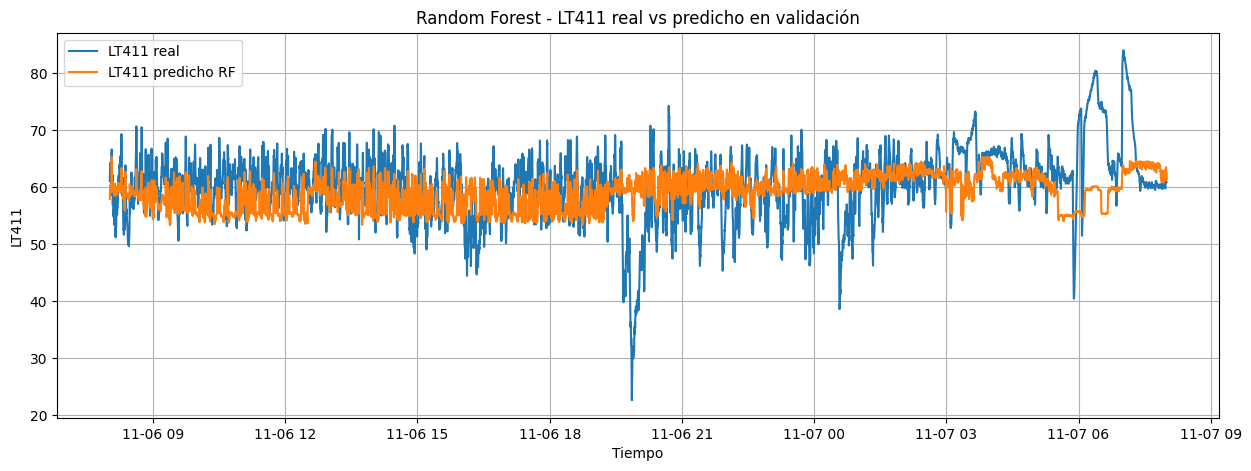

In [13]:
# Graficamos LT411 real frente a predicción en validación

plt.figure(figsize=(15, 5))

plt.plot(valid["Time"], y_valid, label="LT411 real")
plt.plot(valid["Time"], pred_valid_rf, label="LT411 predicho RF")

plt.title("Random Forest - LT411 real vs predicho en validación")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

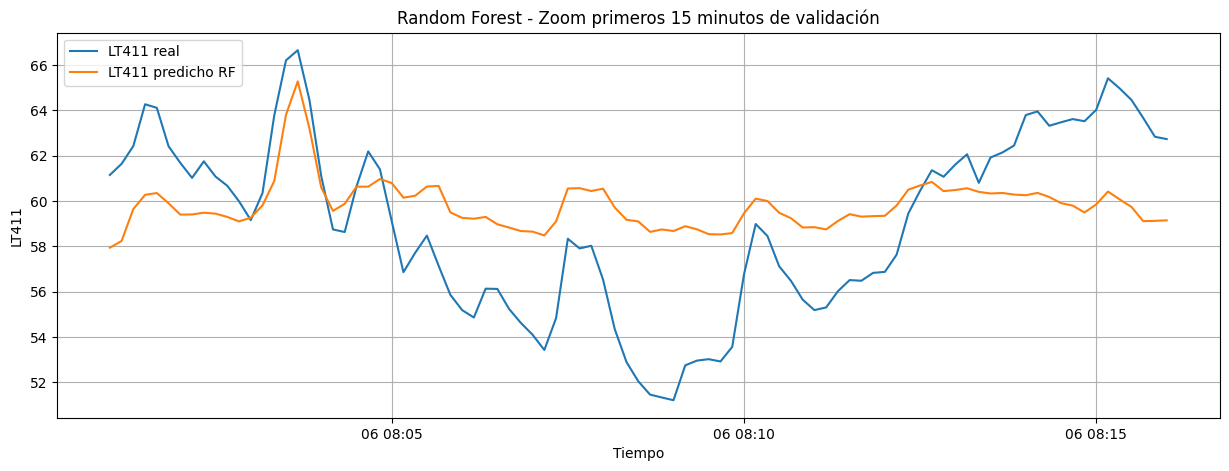

In [14]:
# Graficamos zoom de los primeros 15 minutos de validación

inicio_zoom_15min = valid["Time"].min()

fin_zoom_15min = inicio_zoom_15min + pd.Timedelta(minutes=15)

valid_zoom_15min = valid[
    (valid["Time"] >= inicio_zoom_15min) &
    (valid["Time"] <= fin_zoom_15min)
]

pred_valid_zoom_15min = pred_valid_rf[valid_zoom_15min.index - valid.index.min()]

plt.figure(figsize=(15, 5))

plt.plot(valid_zoom_15min["Time"], valid_zoom_15min["LT411"], label="LT411 real")
plt.plot(valid_zoom_15min["Time"], pred_valid_zoom_15min, label="LT411 predicho RF")

plt.title("Random Forest - Zoom primeros 15 minutos de validación")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

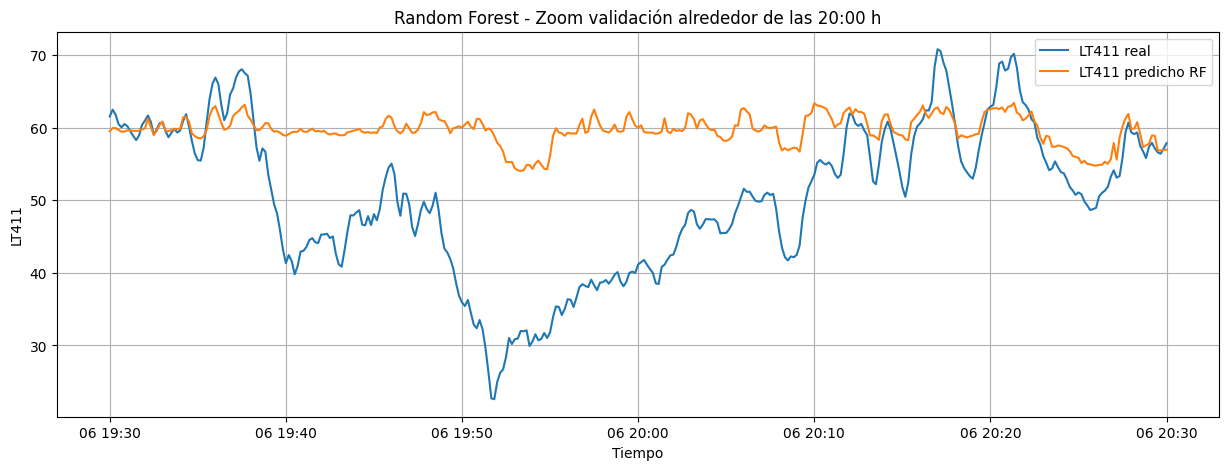

In [15]:
# Graficamos zoom alrededor de las 20:00 h en validación

inicio_zoom_20h = pd.Timestamp("2021-11-06 19:30:00")

fin_zoom_20h = pd.Timestamp("2021-11-06 20:30:00")

valid_zoom_20h = valid[
    (valid["Time"] >= inicio_zoom_20h) &
    (valid["Time"] <= fin_zoom_20h)
]

pred_valid_zoom_20h = pred_valid_rf[valid_zoom_20h.index - valid.index.min()]

plt.figure(figsize=(15, 5))

plt.plot(valid_zoom_20h["Time"], valid_zoom_20h["LT411"], label="LT411 real")
plt.plot(valid_zoom_20h["Time"], pred_valid_zoom_20h, label="LT411 predicho RF")

plt.title("Random Forest - Zoom validación alrededor de las 20:00 h")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
valid_rf = valid.copy()
valid_rf["pred_RF"] = pred_valid_rf

In [17]:
valid_rf = valid.copy()
valid_rf["pred_RF"] = pred_valid_rf

In [18]:
# Calculamos el residual del Random Forest en validación

valid_rf["residual_RF"] = valid_rf["LT411"] - valid_rf["pred_RF"]

valid_rf.head()

,Time,bloque,LT411,DT412,INT_P101,FQC400_1,FV400_1,PT442,PV442,TT413,...,PIT410_roll_mean_3,PIT410_roll_std_3,PIT410_roll_mean_6,PIT410_roll_std_6,PIT414_roll_mean_3,PIT414_roll_std_3,PIT414_roll_mean_6,PIT414_roll_std_6,pred_RF,residual_RF
8634,2021-11-06 08:01:00,validacion,61.148726,1226.132764,59.302661,3318.141260,59.700001,0.154630,0.0,82.026917,...,0.333936,0.000230,0.334154,0.000338,0.593904,0.000267,0.593962,0.000236,57.940502,3.208223
8635,2021-11-06 08:01:10,validacion,61.640624,1226.822864,59.126156,3318.697778,59.700001,0.154398,0.0,82.018237,...,0.333650,0.000267,0.334032,0.000477,0.593866,0.000200,0.594020,0.000215,58.236962,3.403662
8636,2021-11-06 08:01:20,validacion,62.427662,1228.906213,57.893517,3315.788135,59.700001,0.154109,0.0,82.031258,...,0.333777,0.000415,0.334000,0.000456,0.594001,0.000219,0.594030,0.000221,59.646557,2.781104
8637,2021-11-06 08:01:30,validacion,64.267940,1231.002563,57.523148,3315.008569,59.700001,0.153993,0.0,82.031258,...,0.333034,0.001316,0.333485,0.000979,0.594348,0.000385,0.594126,0.000383,60.271388,3.996551
8638,2021-11-06 08:01:40,validacion,64.108797,1229.205676,58.764466,3315.546729,59.700001,0.153704,0.0,82.031258,...,0.332833,0.001292,0.333241,0.000947,0.594965,0.000910,0.594416,0.000842,60.350981,3.757816


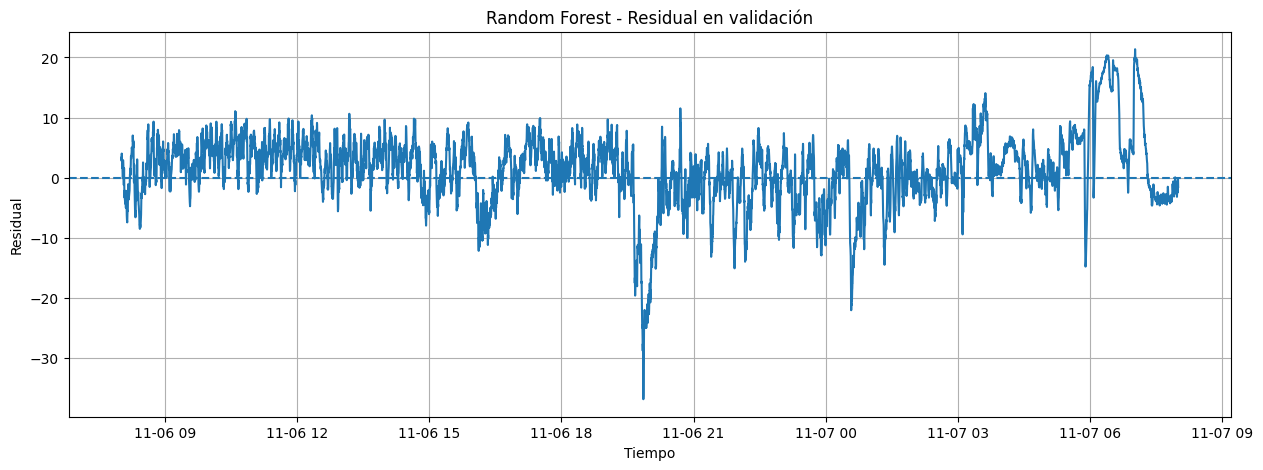

In [19]:
# Graficamos el residual en validación

plt.figure(figsize=(15, 5))

plt.plot(valid_rf["Time"], valid_rf["residual_RF"])

plt.axhline(0, linestyle="--")

plt.title("Random Forest - Residual en validación")
plt.xlabel("Tiempo")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

In [20]:
# Medimos error en los valores altos de LT411

umbral_pico = valid_rf["LT411"].quantile(0.90)

valid_rf["zona_pico"] = valid_rf["LT411"] >= umbral_pico

mae_picos = mean_absolute_error(
    valid_rf[valid_rf["zona_pico"]]["LT411"],
    valid_rf[valid_rf["zona_pico"]]["pred_RF"]
)

mae_no_picos = mean_absolute_error(
    valid_rf[~valid_rf["zona_pico"]]["LT411"],
    valid_rf[~valid_rf["zona_pico"]]["pred_RF"]
)

print("Umbral pico LT411:", umbral_pico)
print("MAE en picos:", mae_picos)
print("MAE fuera de picos:", mae_no_picos)

Umbral pico LT411: 66.4785863494873
MAE en picos: 10.190685447343323
MAE fuera de picos: 3.8871943057901457


In [21]:
# Comparamos rango real y rango predicho en validación

print("LT411 real mínimo:", valid_rf["LT411"].min())
print("LT411 real máximo:", valid_rf["LT411"].max())

print("Predicción RF mínima:", valid_rf["pred_RF"].min())
print("Predicción RF máxima:", valid_rf["pred_RF"].max())

LT411 real mínimo: 22.586804962158208
LT411 real máximo: 84.07986068725587
Predicción RF mínima: 53.36282081301354
Predicción RF máxima: 65.27708216212444


#Esto confirma amortiguación.

In [25]:
# Definimos modelos para comparar en validación

modelos = {
    "LinearRegression": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    
    "Ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    
    "SVR": make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, epsilon=0.1)
    )
}

In [26]:
# Entrenamos modelos y evaluamos en train y validación

resultados = []

modelos_entrenados = {}

for nombre, modelo in modelos.items():
    
    modelo.fit(X_train, y_train)
    
    modelos_entrenados[nombre] = modelo
    
    pred_train = modelo.predict(X_train)
    pred_valid = modelo.predict(X_valid)
    
    mae_train, rmse_train, r2_train = calcular_metricas(y_train, pred_train)
    mae_valid, rmse_valid, r2_valid = calcular_metricas(y_valid, pred_valid)
    
    resultados.append({
        "modelo": nombre,
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_valid": mae_valid,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid
    })

In [27]:
# Creamos tabla comparativa de modelos

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values("MAE_valid").reset_index(drop=True)

df_resultados

,modelo,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,RandomForest,1.128609,1.475923,0.833619,4.517981,6.148864,0.006971
1,SVR,0.746335,1.140236,0.900696,4.614087,6.269312,-0.032315
2,GradientBoosting,1.544135,1.941353,0.712137,4.823460,6.442841,-0.090252
3,Ridge,1.695665,2.163560,0.642468,33.236197,80.970082,-171.195341
4,LinearRegression,1.688647,2.157570,0.644446,34.681263,84.201075,-185.211931


In [ ]:
#En la primera comparativa del Modelo A, RandomForest obtiene el mejor MAE de validación, 
#seguido muy de cerca por SVR. Sin embargo, ambos modelos presentan R² de validación bajo
#y predicciones suavizadas,
#por lo que todavía no se considera cerrado el modelo final.